<a href="https://colab.research.google.com/github/626-NRB/ADS-Data-Analysis-07202026/blob/main/ADS_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ADS DATA ANALYSIS 07/26/26**

**Import the following modules**

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import scipy.stats as scp
import seaborn as sb
import matplotlib.pyplot as plt
!pip install pyreadstat
!pip install researchpy
import researchpy as rp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 27.4 MB/s eta 0:00:00


**Mount the Google Drive**

If any problem arises with the drive mounting, sign in to your google account. Grant all permissions that they ask for.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


The following line shows the path of the dataset at which it will be read. If you had to fix the drive mounting and may have stored the csv file elsewhere, find it, copy the filepath, and update it in the codeblock below. It is important that you download the csv file first and then upload it to google drive.

In [ ]:
SGO_ADSIR21 = pd.read_csv('/content/drive/MyDrive/SGO-2021-01_Incident_Reports_ADS.csv')

# **ALL THE QUESTIONS ARE BELOW THIS TEXT ↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓**

### A. *What is the distribution of roadways in the incident reports? [Check the field 52: &lt;Roadway Type&gt; and try to plot bar chart by types and develop count tables]*

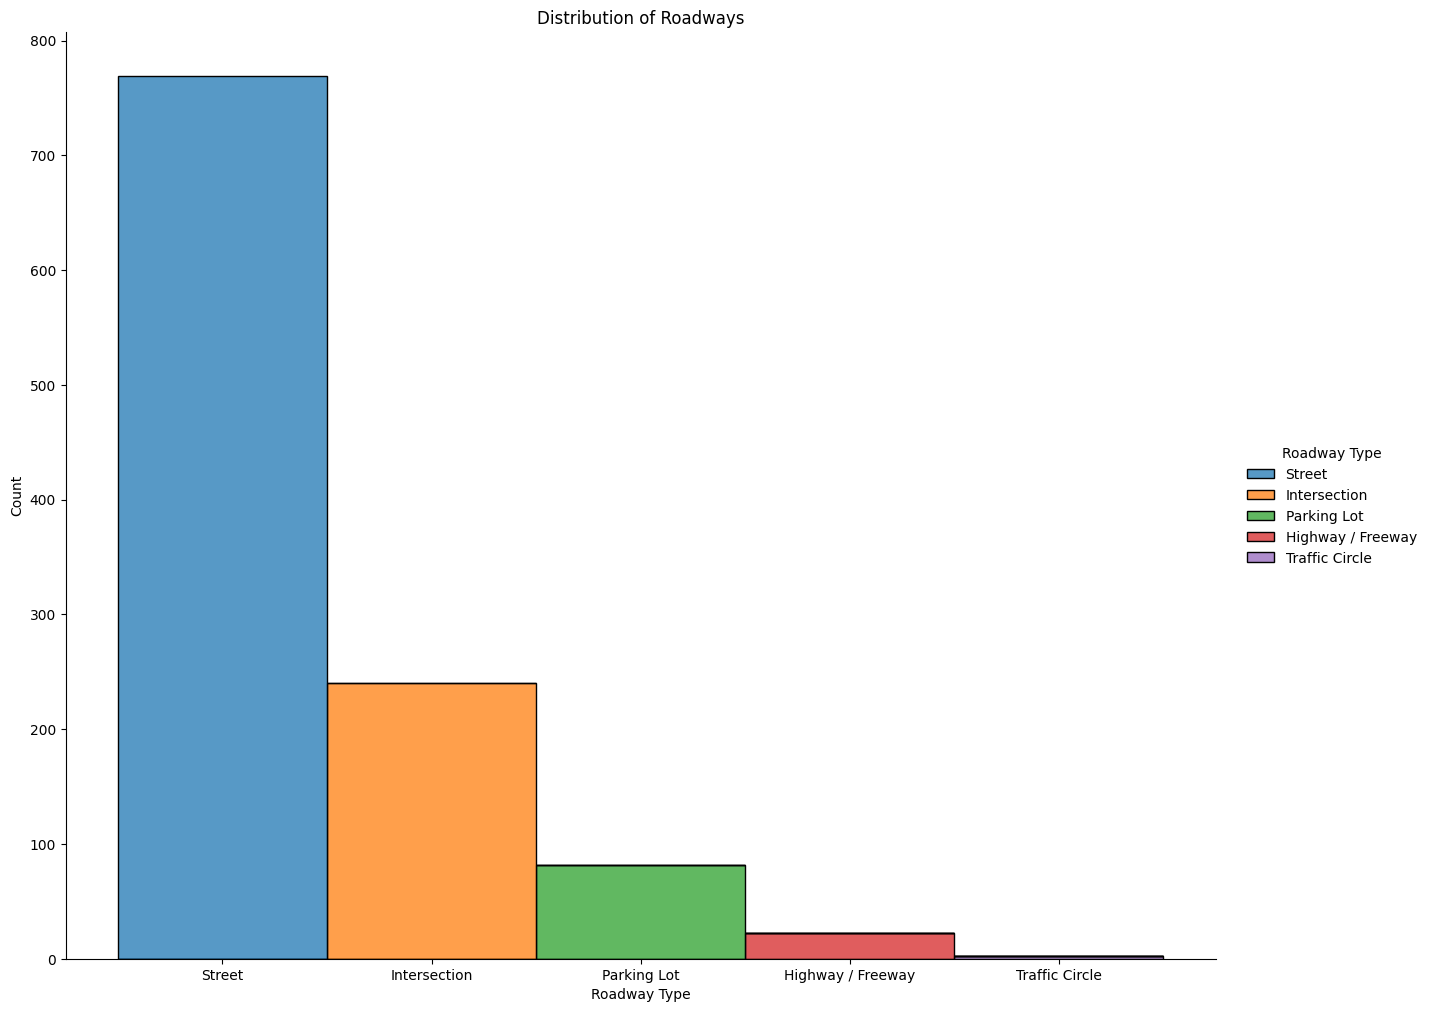

In [ ]:
p = sb.displot(SGO_ADSIR21, x='Roadway Type', hue='Roadway Type', multiple="stack", height=10, aspect=1.25)
plt.title('Distribution of Roadways')
plt.show()

In [ ]:
counts = SGO_ADSIR21['Roadway Type'].value_counts(dropna=False)
percentages = SGO_ADSIR21['Roadway Type'].value_counts(dropna=False, normalize=True) * 100

table_df = pd.DataFrame({
    'Roadway Type': counts.index.fillna('Missing / Unknown'),
    'Count': counts.values,
    'Percentage (%)': percentages.round(2).values
})

print("=== Distribution of Roadways ===")
print(table_df.to_string(index=False))

=== Distribution of Roadways ===
     Roadway Type  Count  Percentage (%)
           Street    769           68.97
     Intersection    240           21.52
      Parking Lot     82            7.35
Highway / Freeway     22            1.97
   Traffic Circle      2            0.18


### B. *What is the role of existing road or traffic conditions on the incidents?  [Create new variable/column using the fields 53, 54, 55, and 57; and try to answer the question]*

In [ ]:
col_degraded = SGO_ADSIR21.columns[52]  # Column 53: Roadway-Degraded Surface
col_markings = SGO_ADSIR21.columns[53]  # Column 54: Roadway-Missing/Degraded Marking
col_normal   = SGO_ADSIR21.columns[54]  # Column 55: Roadway-No Unusual Conditions
col_incident = SGO_ADSIR21.columns[56]  # Column 57: Roadway-Traffic Incident

print("Mapping the following columns to create the new variables:")
print(f"col_degraded")
print(f"col_markings")
print(f"col_normal")
print(f"col_incident")

def determine_road_condition(row):
    conditions = []
    if str(row[col_normal]).strip().upper() == 'Y':
        conditions.append("Normal/No Unusual Conditions")
    if str(row[col_degraded]).strip().upper() == 'Y':
        conditions.append("Degraded Surface")
    if str(row[col_markings]).strip().upper() == 'Y':
        conditions.append("Missing/Degraded Markings")
    if str(row[col_incident]).strip().upper() == 'Y':
        conditions.append("Active Traffic Incident")

    if not conditions:
        return "Unknown/Other"
    elif len(conditions) > 1:
        if "Normal/No Unusual Conditions" in conditions:
            conditions.remove("Normal/No Unusual Conditions")
        return " & ".join(conditions) if len(conditions) > 1 else conditions[0]
    else:
        return conditions[0]

SGO_ADSIR21['Road_Condition_Category'] = SGO_ADSIR21.apply(determine_road_condition, axis=1)

stats = SGO_ADSIR21['Road_Condition_Category'].value_counts().reset_index()
stats.columns = ['Road Condition Category', 'Incident Count']
stats['Percentage (%)'] = ((stats['Incident Count'] / len(SGO_ADSIR21)) * 100).round(2)

print("=== Descriptive Statistics: Role of Road & Traffic Conditions ===")
print(stats)

Mapping the following columns to create the new variables:
col_degraded
col_markings
col_normal
col_incident
=== Descriptive Statistics: Role of Road & Traffic Conditions ===
        Road Condition Category  Incident Count  Percentage (%)
0  Normal/No Unusual Conditions            1032           92.56
1                 Unknown/Other              70            6.28
2              Degraded Surface               8            0.72
3       Active Traffic Incident               4            0.36
4     Missing/Degraded Markings               1            0.09


C. Do we have incidents in work zones? [Check field 60, and build your own
descriptive statistics]

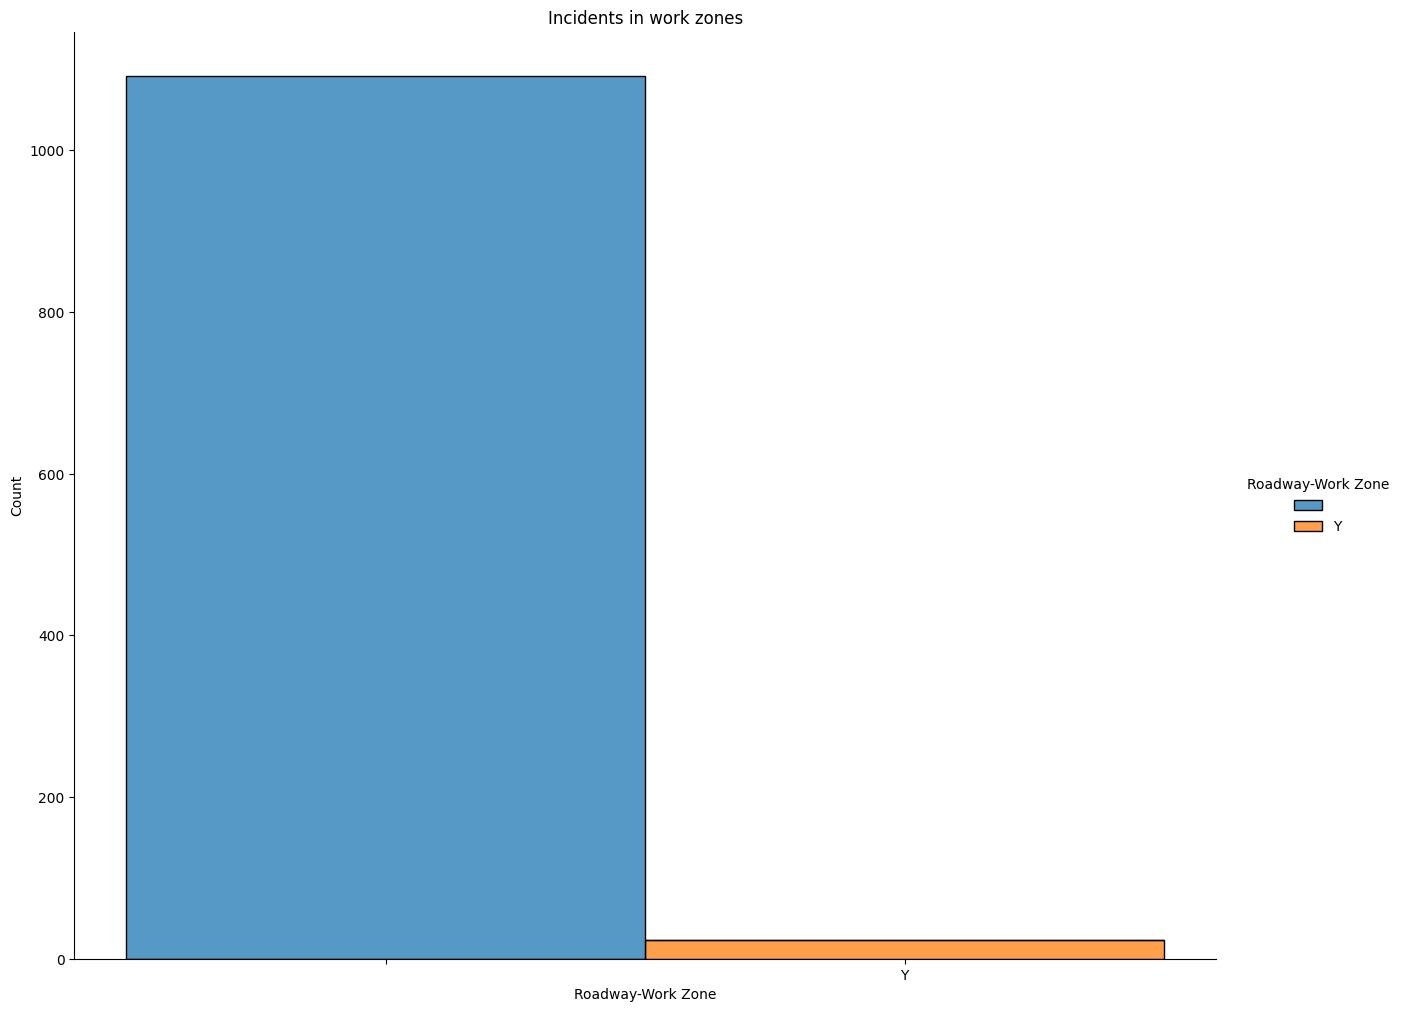

In [ ]:
p = sb.displot(SGO_ADSIR21, x='Roadway-Work Zone', hue='Roadway-Work Zone', multiple="stack", height=10, aspect=1.25)
plt.title('Incidents in work zones')
plt.show()

In [ ]:
work_zone_col = SGO_ADSIR21.columns[59]

clean_work_zone = SGO_ADSIR21[work_zone_col].astype(str).str.strip()
clean_work_zone = clean_work_zone.replace('', 'N (Not Marked)')

work_zone_counts = clean_work_zone.value_counts().reset_index()
work_zone_counts.columns = ['Roadway - Work Zone', 'Incident Count']
work_zone_counts['Percentage (%)'] = ((work_zone_counts['Incident Count'] / len(SGO_ADSIR21)) * 100).round(2)

print(work_zone_counts.to_string(index=False))

Roadway - Work Zone  Incident Count  Percentage (%)
     N (Not Marked)            1092           97.94
                  Y              23            2.06


D. How did weather related factors affect the incidents? [Check field 61- 71, and
build your own descriptive statistics]

In [ ]:
weather_cols = SGO_ADSIR21.columns[60:71]

weather_counts = {}
total_records = len(SGO_ADSIR21)

for col in weather_cols:
    clean_series = SGO_ADSIR21[col].astype(str).str.strip().str.upper()
    count_y = (clean_series == 'Y').sum()
    weather_counts[col] = count_y

weather_df = pd.DataFrame(list(weather_counts.items()), columns=['Weather Condition', 'Incident Count'])
weather_df['Percentage (%)'] = ((weather_df['Incident Count'] / total_records) * 100).round(2)

weather_df = weather_df.sort_values(by='Incident Count', ascending=False)

print("=== Descriptive Statistics: Weather-Related Factors ===")
print(weather_df.to_string(index=False))

multi_weather = SGO_ADSIR21[weather_cols].apply(lambda row: (row.astype(str).str.strip().str.upper() == 'Y').sum(), axis=1)
print(f"\nIncidents with multiple weather conditions reported: {len(SGO_ADSIR21[multi_weather > 1])} ({round((len(SGO_ADSIR21[multi_weather > 1])/total_records)*100, 2)}%)")

=== Descriptive Statistics: Weather-Related Factors ===
            Weather Condition  Incident Count  Percentage (%)
              Weather - Clear             833           74.71
             Weather - Cloudy             152           13.63
      Weather - Partly Cloudy              88            7.89
               Weather - Rain              49            4.39
   Weather - Structure-Indoor               2            0.18
               Weather - Snow               0            0.00
     Weather - Fog/Smoke/Haze               0            0.00
        Weather - Severe Wind               0            0.00
         Weather - Dust Storm               0            0.00
   Weather - Severe Hurricane               0            0.00
Weather - Unk - See Narrative               0            0.00

Incidents with multiple weather conditions reported: 9 (0.81%)


E. What is the most crash-with (the ADS hits which other entity) group? [Check
field 72; and build your own descriptive statistics]

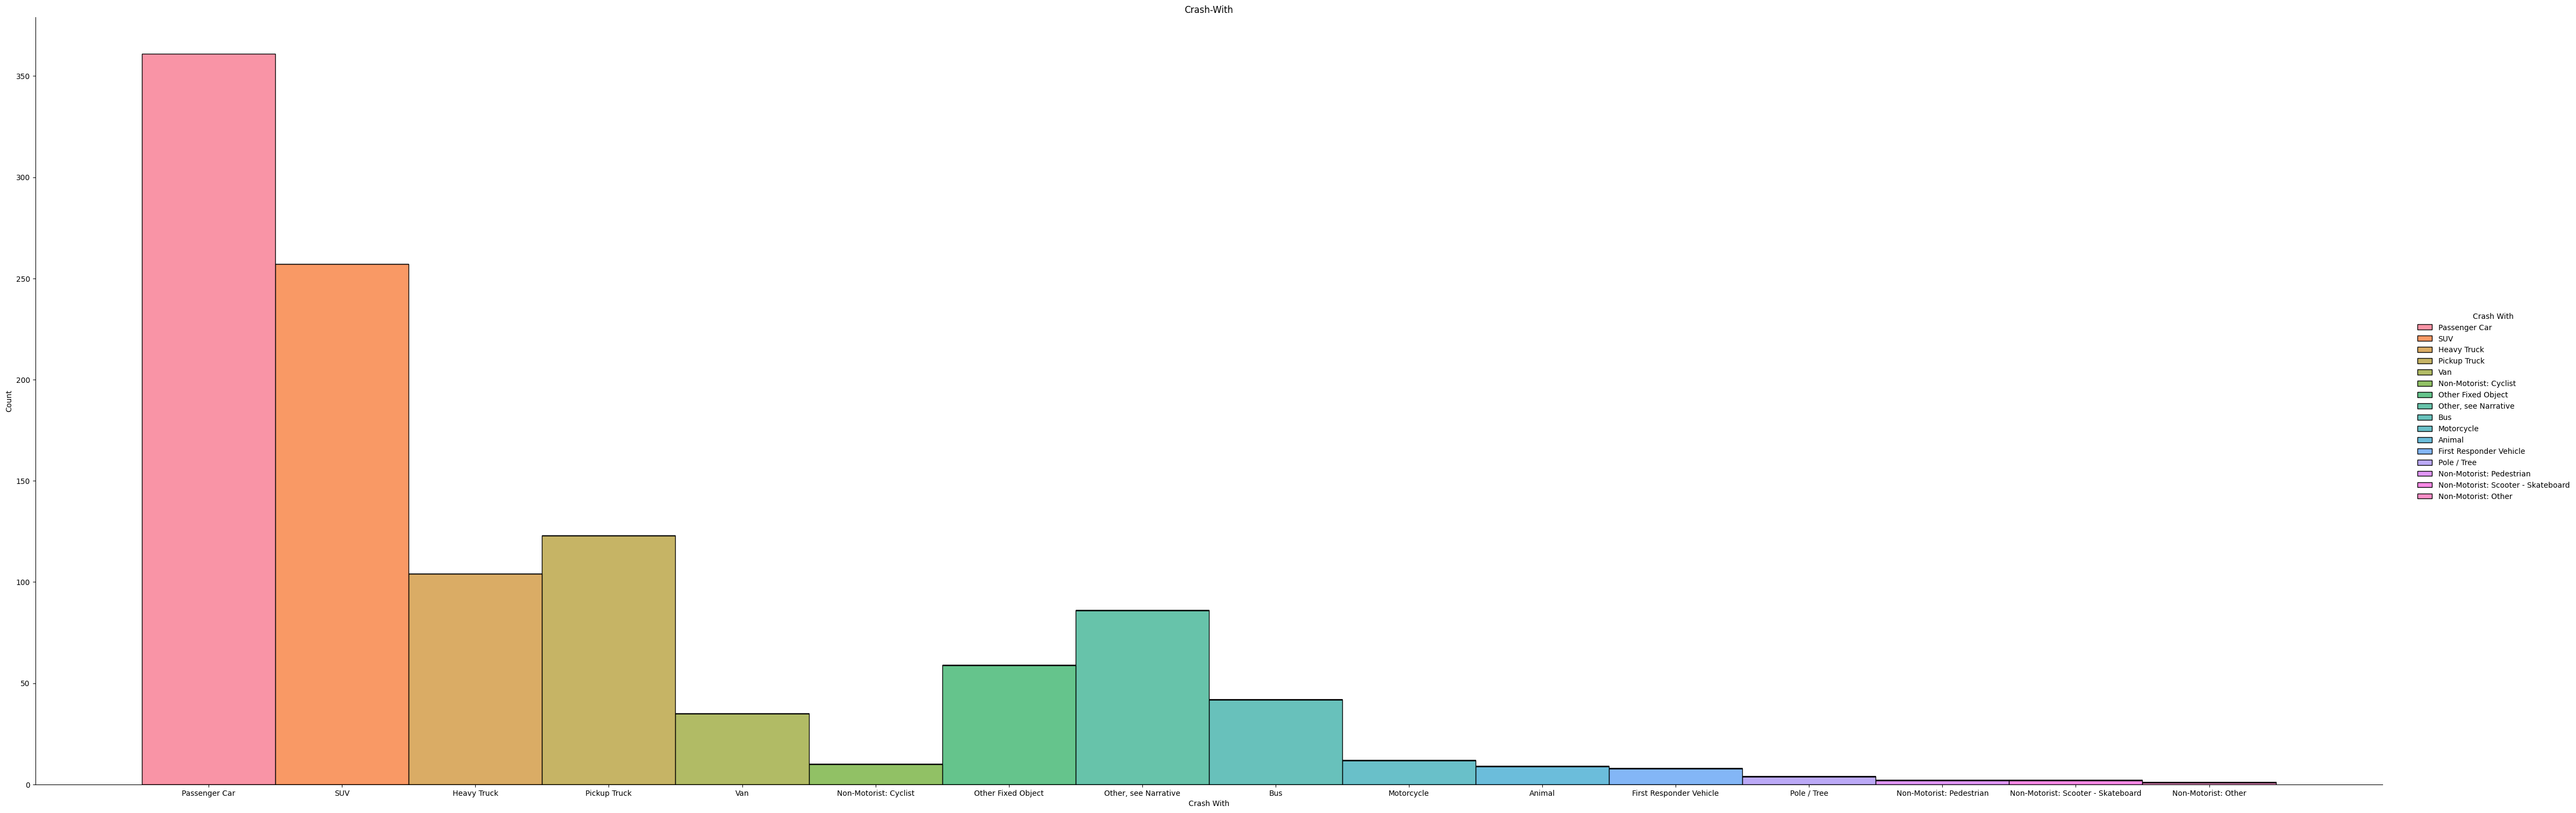

In [ ]:
p = sb.displot(SGO_ADSIR21, x='Crash With', hue='Crash With', multiple="stack", height=15, aspect=3)
plt.title('Crash-With')
plt.show()

In [ ]:
total_rows = len(SGO_ADSIR21)
counts = SGO_ADSIR21['Crash With'].value_counts(dropna=False)
percentages = (counts / total_rows) * 100
cumulative_percentages = percentages.cumsum()

table_df = pd.DataFrame({
    'Crash With Entity': counts.index,
    'Frequency (Count)': counts.values,
    'Percentage (%)': percentages.round(2).values,
})

print("--- Descriptive Statistics Table ---")
print(table_df.to_string(index=False))

--- Descriptive Statistics Table ---
                 Crash With Entity  Frequency (Count)  Percentage (%)
                     Passenger Car                361           32.38
                               SUV                257           23.05
                      Pickup Truck                123           11.03
                       Heavy Truck                104            9.33
              Other, see Narrative                 86            7.71
                Other Fixed Object                 59            5.29
                               Bus                 42            3.77
                               Van                 35            3.14
                        Motorcycle                 12            1.08
             Non-Motorist: Cyclist                 10            0.90
                            Animal                  9            0.81
           First Responder Vehicle                  8            0.72
                       Pole / Tree                  4

F. What are the outcomes from the incidents [Check field 73, and build your own
descriptive statistics]?

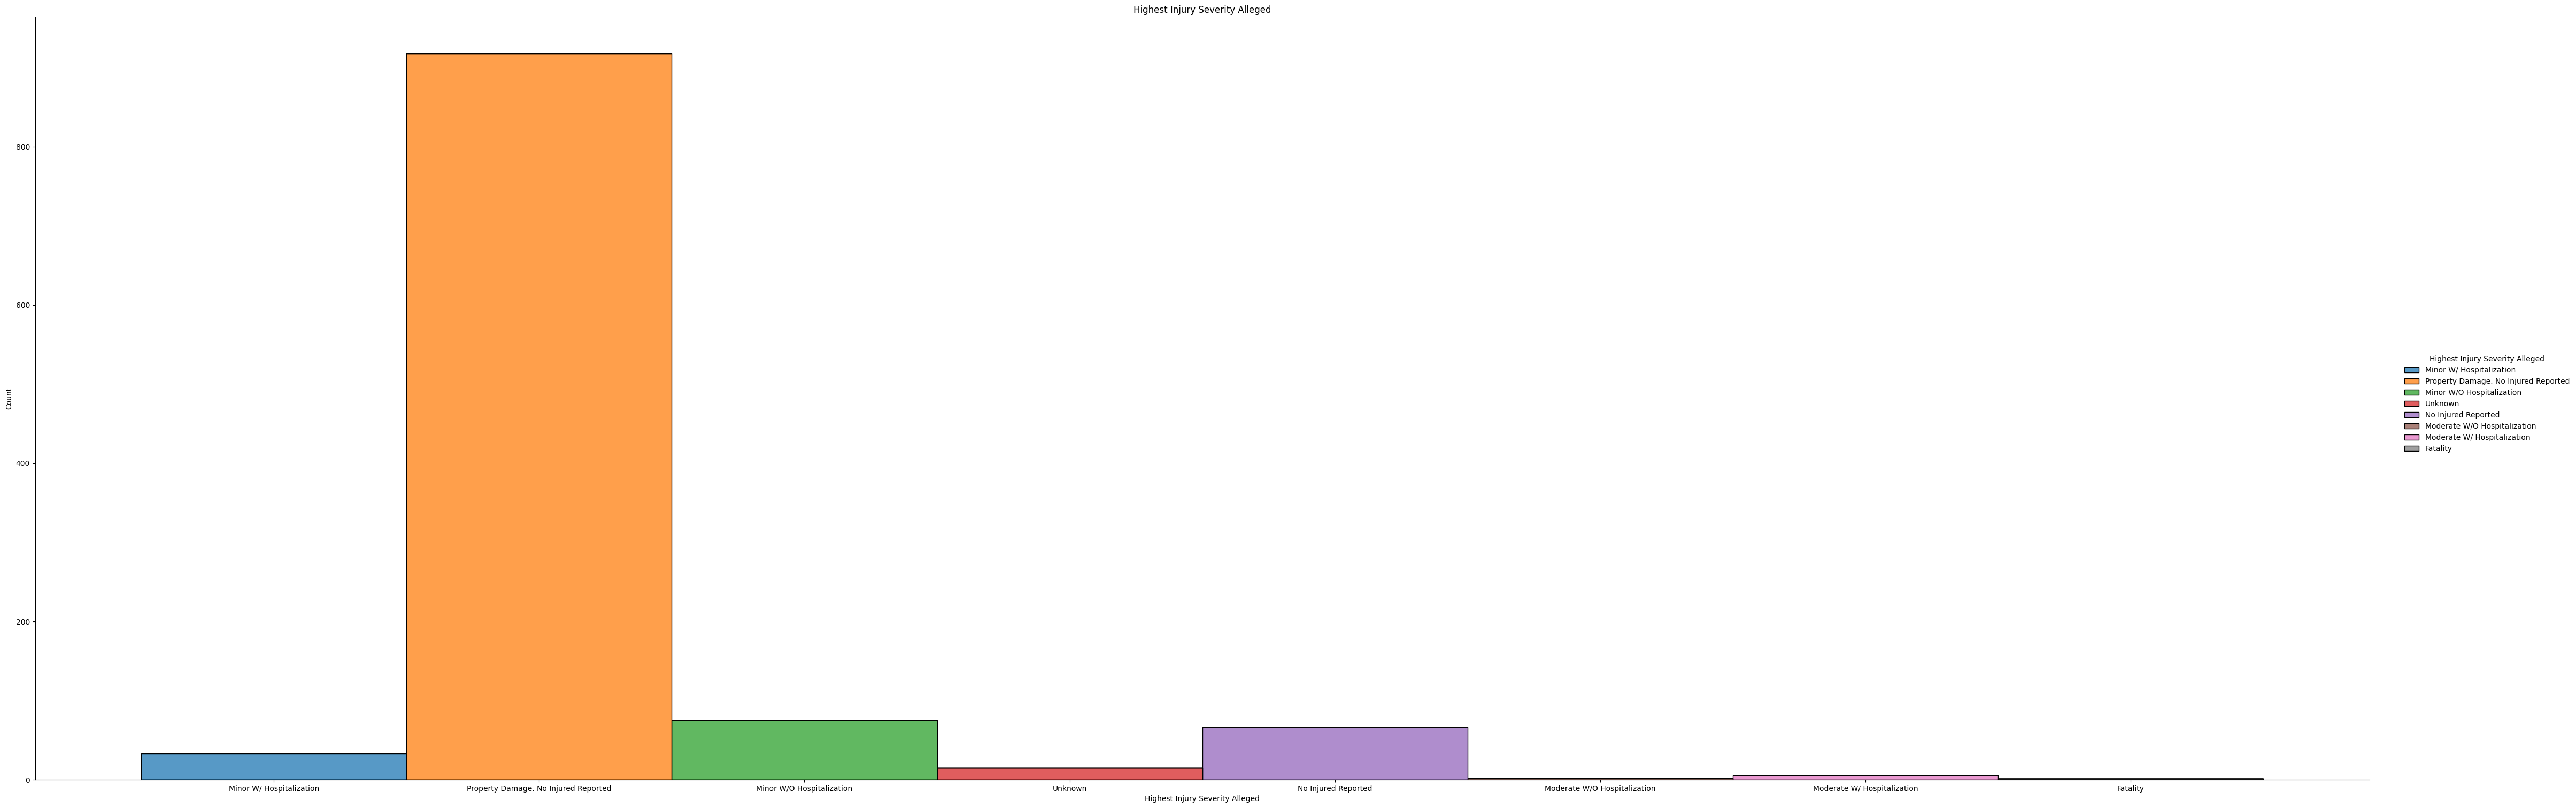

In [ ]:
p = sb.displot(SGO_ADSIR21, x='Highest Injury Severity Alleged', hue='Highest Injury Severity Alleged', multiple="stack", height=15, aspect=3)
plt.title('Highest Injury Severity Alleged')
plt.show()

In [ ]:
counts = SGO_ADSIR21['Highest Injury Severity Alleged'].value_counts(dropna=False)
percentages = SGO_ADSIR21['Highest Injury Severity Alleged'].value_counts(dropna=False, normalize=True) * 100

table_df = pd.DataFrame({
    'Highest Injury Severity Alleged': counts.index,
    'Count': counts.values,
    'Percentage (%)': percentages.round(2).values
})

print("=== Highest Injury Severity Alleged Table ===")
print(table_df.to_string(index=False))

=== Highest Injury Severity Alleged Table ===
     Highest Injury Severity Alleged  Count  Percentage (%)
Property Damage. No Injured Reported    918           82.33
           Minor W/O Hospitalization     75            6.73
                 No Injured Reported     66            5.92
            Minor W/ Hospitalization     33            2.96
                             Unknown     15            1.35
         Moderate W/ Hospitalization      5            0.45
        Moderate W/O Hospitalization      2            0.18
                            Fatality      1            0.09


G. What are the most common crash patterns? [Check field 74 and 86, and build
your own descriptive statistics; you need to do some data manipulation and think
about the information]

In [ ]:
filtered_df = SGO_ADSIR21.dropna(subset=["CP Pre-Crash Movement", "SV Pre-Crash Movement"]).copy()

filtered_df["CP Pre-Crash Movement"] = filtered_df["CP Pre-Crash Movement"].astype(str).str.strip()
filtered_df["SV Pre-Crash Movement"] = filtered_df["SV Pre-Crash Movement"].astype(str).str.strip()

filtered_df = filtered_df[
    (filtered_df["CP Pre-Crash Movement"] != "") &
    (~filtered_df["CP Pre-Crash Movement"].str.contains("Unknown", case=False)) &
    (filtered_df["SV Pre-Crash Movement"] != "") &
    (~filtered_df["SV Pre-Crash Movement"].str.contains("Unknown", case=False))
]

print("=== CP Pre-Crash Movement Distribution (Unknowns Eliminated) ===")
print(filtered_df["CP Pre-Crash Movement"].value_counts().to_string())

print("\n=== SV Pre-Crash Movement Distribution (Unknowns Eliminated) ===")
print(filtered_df["SV Pre-Crash Movement"].value_counts().to_string())

print("\n=== Most Common Crash Patterns (SV Movement vs. CP Movement) ===")

crash_patterns = (
    filtered_df.groupby(["SV Pre-Crash Movement", "CP Pre-Crash Movement"])
    .size()
    .reset_index(name="Count")
    .sort_values(by="Count", ascending=False)
)

crash_patterns["Percentage"] = (
    (crash_patterns["Count"] / len(filtered_df)) * 100
).round(2)

print(crash_patterns.head(15).to_string(index=False))

=== CP Pre-Crash Movement Distribution (Unknowns Eliminated) ===
CP Pre-Crash Movement
Proceeding Straight            398
Backing                        123
Passing                        121
Other, see Narrative            98
Changing Lanes                  65
Making Right Turn               64
Making Left Turn                50
Entering Traffic                32
Parked                          26
Stopped                         22
Crossing into Opposing Lane     12
Traveling Wrong Way             10
Parking Maneuver                 9
Lane / Road Departure            8
NM Crossing Roadway              5
Merging                          3
NM Moving Alongside Roadway      2
NM Waiting to Cross Roadway      1
Making U-Turn                    1

=== SV Pre-Crash Movement Distribution (Unknowns Eliminated) ===
SV Pre-Crash Movement
Stopped                  481
Proceeding Straight      351
Parked                    87
Making Left Turn          41
Making Right Turn         28
Changing Lanes 

# **SUMMARY**

https://docs.google.com/document/d/1ATxSfnOut-WYi1iOt3bBq6KhSyLFLYYVOV1GzHygc-Y/edit?usp=sharing